# Allergy Medication Response Classification 

Student: Anastasiya Khralovich  
Group: MZ301L

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, spearmanr, f_oneway, kruskal
from sklearn.model_selection import StratifiedKFold
from scipy.stats import f_oneway, kruskal, shapiro, levene
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from lightgbm import LGBMClassifier


import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

plt.style.use('default')
%matplotlib inline

## Load Data

In [2]:
train_df = pd.read_excel("train_allergy.xlsx")
test_df = pd.read_excel("test_allergy.xlsx")

print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")
print(f"\nOriginal target distribution:")
print(train_df['response_class'].value_counts())

Train: (500, 11)
Test: (100, 10)

Original target distribution:
response_class
Effective              193
Partially Effective    159
Ineffective            148
Name: count, dtype: int64


In [3]:
train_df.head()

,age,gender,allergy_type,symptom_severity,medication_type,dosage_mg,treatment_duration_days,comorbid_conditions,previous_response,environmental_exposure,response_class
0,6,Female,dust,Mild,Antihistamine,47.4,15,Asthma,Good,Low,Partially Effective
1,6,Male,food,Severe,Antihistamine,9.5,54,Eczema,NaN,Medium,Partially Effective
2,64,Male,pollen,Severe,Corticosteroid,17.1,19,Asthma,Good,Medium,Ineffective
3,35,Male,dust,Severe,Antihistamine,56.5,44,Asthma,NaN,Medium,Effective
4,25,Other,pet dander,Moderate,Corticosteroid,88.8,43,Eczema,Poor,Low,Effective


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      500 non-null    int64  
 1   gender                   500 non-null    object 
 2   allergy_type             500 non-null    object 
 3   symptom_severity         500 non-null    object 
 4   medication_type          500 non-null    object 
 5   dosage_mg                500 non-null    float64
 6   treatment_duration_days  500 non-null    int64  
 7   comorbid_conditions      324 non-null    object 
 8   previous_response        327 non-null    object 
 9   environmental_exposure   500 non-null    object 
 10  response_class           500 non-null    object 
dtypes: float64(1), int64(2), object(8)
memory usage: 43.1+ KB


In [5]:
print(train_df['allergy_type'].unique())
print(train_df['symptom_severity'].unique()) 
print(train_df['medication_type'].unique())
print(train_df['comorbid_conditions'].unique())
print(train_df['previous_response'].unique()) 
print(train_df['environmental_exposure'].unique()) 
print(train_df['response_class'].unique()) 

['dust' 'food' 'pollen' 'pet dander']
['Mild' 'Severe' 'Moderate']
['Antihistamine' 'Corticosteroid']
['Asthma' 'Eczema' nan]
['Good' nan 'Poor']
['Low' 'Medium' 'High']
['Partially Effective' 'Ineffective' 'Effective']


In [6]:
#missing values
print(train_df.isnull().sum())

age                          0
gender                       0
allergy_type                 0
symptom_severity             0
medication_type              0
dosage_mg                    0
treatment_duration_days      0
comorbid_conditions        176
previous_response          173
environmental_exposure       0
response_class               0
dtype: int64


In [7]:
#numerical features
train_df[['age', 'dosage_mg', 'treatment_duration_days']].describe()

,age,dosage_mg,treatment_duration_days
count,500.000000,500.000000,500.000000
mean,48.834000,52.403200,30.548000
std,24.826662,27.202659,17.279956
min,5.000000,5.300000,1.000000
25%,28.000000,29.475000,15.000000
50%,50.000000,52.250000,30.000000
75%,71.250000,74.625000,47.000000
max,90.000000,100.000000,60.000000


In [8]:
#categorical features
cat_cols = ['gender', 'allergy_type', 'medication_type', 'symptom_severity',
            'environmental_exposure', 'comorbid_conditions', 'previous_response']

for col in cat_cols:
    print(f"\n{col}:")
    print(train_df[col].value_counts(dropna=False))


gender:
gender
Other     189
Male      163
Female    148
Name: count, dtype: int64

allergy_type:
allergy_type
dust          131
pollen        124
pet dander    124
food          121
Name: count, dtype: int64

medication_type:
medication_type
Corticosteroid    264
Antihistamine     236
Name: count, dtype: int64

symptom_severity:
symptom_severity
Moderate    174
Severe      166
Mild        160
Name: count, dtype: int64

environmental_exposure:
environmental_exposure
Low       176
Medium    163
High      161
Name: count, dtype: int64

comorbid_conditions:
comorbid_conditions
Eczema    178
NaN       176
Asthma    146
Name: count, dtype: int64

previous_response:
previous_response
Good    175
NaN     173
Poor    152
Name: count, dtype: int64


## Data cleanup

In [9]:
def create_features(df):
    df = df.copy()
    
    # Fill NaNs
    df['comorbid_conditions'] = df['comorbid_conditions'].fillna('None')
    df['previous_response'] = df['previous_response'].fillna('Unknown')
    
    # Ordinal encoding
    severity_map = {'Mild': 0, 'Moderate': 1, 'Severe': 2}
    df['symptom_severity_ord'] = df['symptom_severity'].map(severity_map)

    exposure_map = {'Low': 0, 'Medium': 1, 'High': 2}
    df['environmental_exposure_ord'] = df['environmental_exposure'].map(exposure_map)
    
    # Engineered features
    df['dosage_intensity'] = df['dosage_mg'] / (df['treatment_duration_days'] + 1)
    df['gender_severity'] = df['gender'].astype(str) + "_" + df['symptom_severity'].astype(str)
    df['severity_medication'] = df['symptom_severity'].astype(str) + "_" + df['medication_type'].astype(str)
    df['comorbid_severity'] = df['comorbid_conditions'].astype(str) + "_" + df['symptom_severity'].astype(str)
    df['age_group'] = pd.cut(df['age'], bins=[0, 18, 65, 100], labels=['Child', 'Adult', 'Senior'])
    df['age_group'] = df['age_group'].astype(str)
    
    return df

train_df = create_features(train_df)
test_df = create_features(test_df)


In [10]:


target_map = {'Ineffective': 0, 'Partially Effective': 1, 'Effective': 2}
train_df['response_class_ord'] = train_df['response_class'].map(target_map)


In [11]:
train_df[['symptom_severity', 'symptom_severity_ord',  'response_class', 'response_class_ord']].head()

,symptom_severity,symptom_severity_ord,response_class,response_class_ord
0,Mild,0,Partially Effective,1
1,Severe,2,Partially Effective,1
2,Severe,2,Ineffective,0
3,Severe,2,Effective,2
4,Moderate,1,Effective,2


## Vizualizations

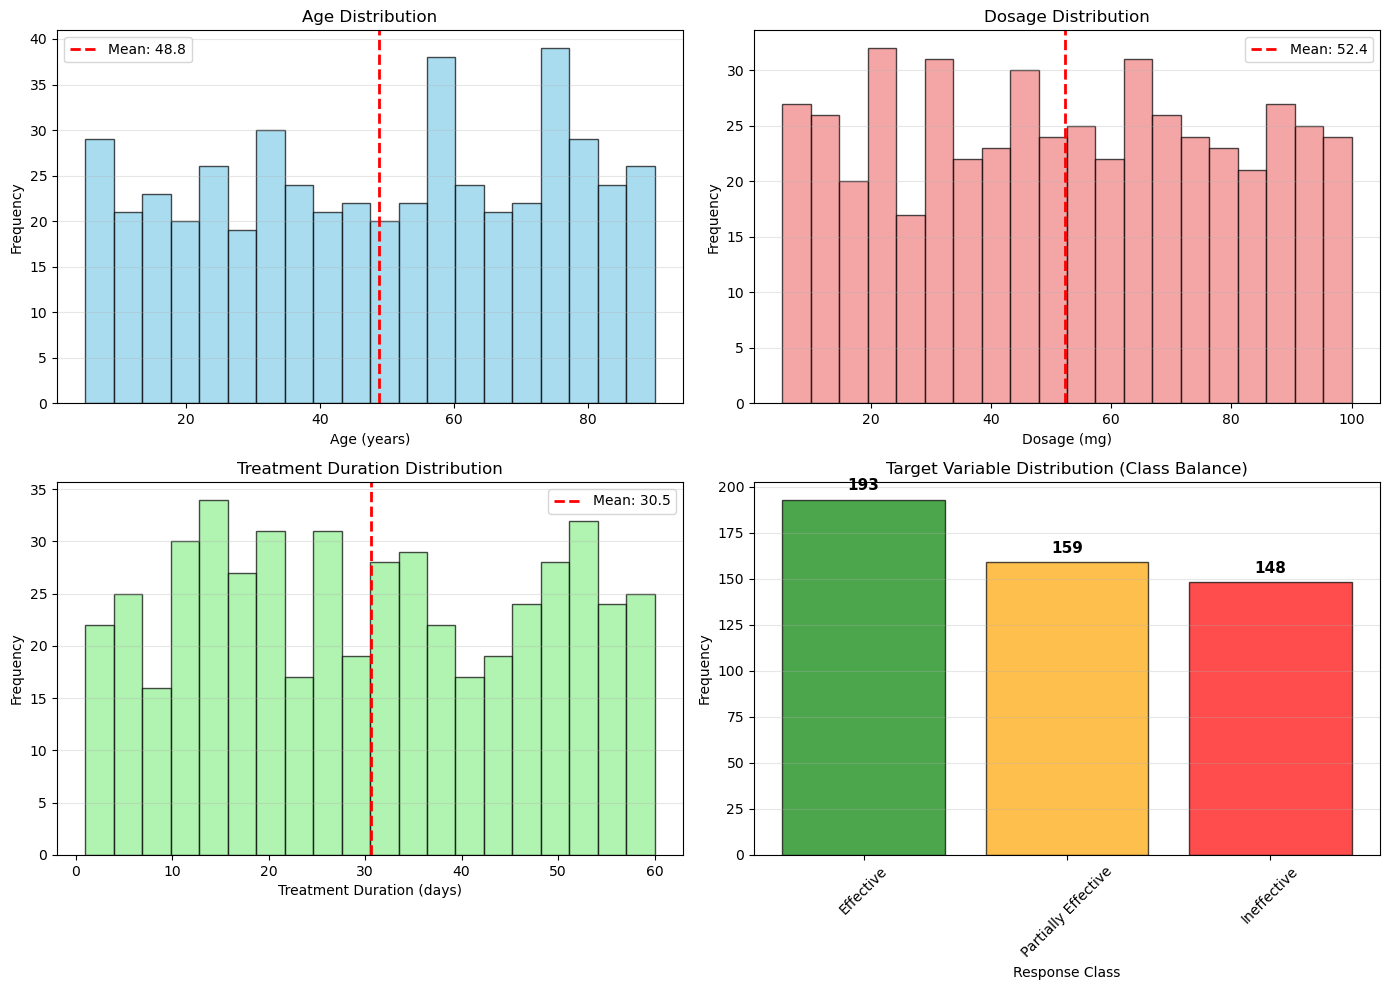

In [12]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age 
axes[0, 0].hist(train_df['age'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Age (years)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].axvline(train_df['age'].mean(), color='red', linestyle='--', 
                    linewidth=2, label=f'Mean: {train_df["age"].mean():.1f}')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Dosage
axes[0, 1].hist(train_df['dosage_mg'], bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Dosage (mg)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Dosage Distribution')
axes[0, 1].axvline(train_df['dosage_mg'].mean(), color='red', linestyle='--', 
                    linewidth=2, label=f'Mean: {train_df["dosage_mg"].mean():.1f}')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Treatment duration 
axes[1, 0].hist(train_df['treatment_duration_days'], bins=20, color='lightgreen', 
                edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Treatment Duration (days)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Treatment Duration Distribution')
axes[1, 0].axvline(train_df['treatment_duration_days'].mean(), color='red', 
                    linestyle='--', linewidth=2, 
                    label=f'Mean: {train_df["treatment_duration_days"].mean():.1f}')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

response_counts = train_df['response_class'].value_counts()
axes[1, 1].bar(response_counts.index, response_counts.values, color=['green', 'orange', 'red'], 
               edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Response Class')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Target Variable Distribution (Class Balance)')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

for i, (label, count) in enumerate(response_counts.items()):
    axes[1, 1].text(i, count + 5, str(count), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

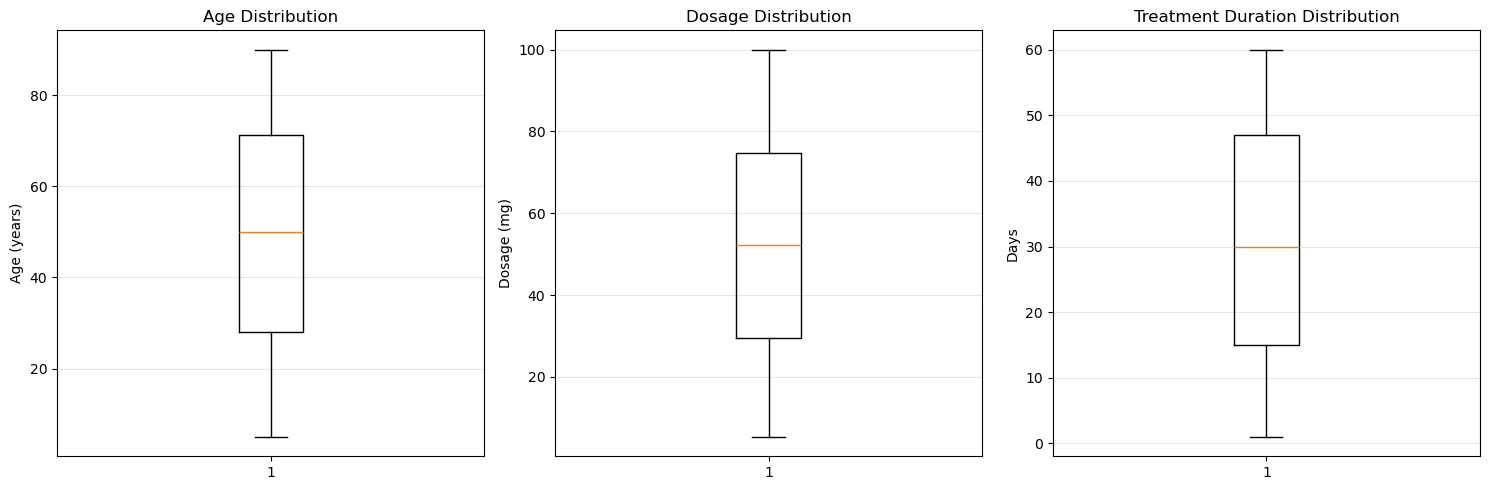

In [13]:
#outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Age 
axes[0].boxplot(train_df['age'], vert=True)
axes[0].set_ylabel('Age (years)')
axes[0].set_title('Age Distribution')
axes[0].grid(axis='y', alpha=0.3)

# Dosage
axes[1].boxplot(train_df['dosage_mg'], vert=True)
axes[1].set_ylabel('Dosage (mg)')
axes[1].set_title('Dosage Distribution')
axes[1].grid(axis='y', alpha=0.3)

# Treatment duration
axes[2].boxplot(train_df['treatment_duration_days'], vert=True)
axes[2].set_ylabel('Days')
axes[2].set_title('Treatment Duration Distribution')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

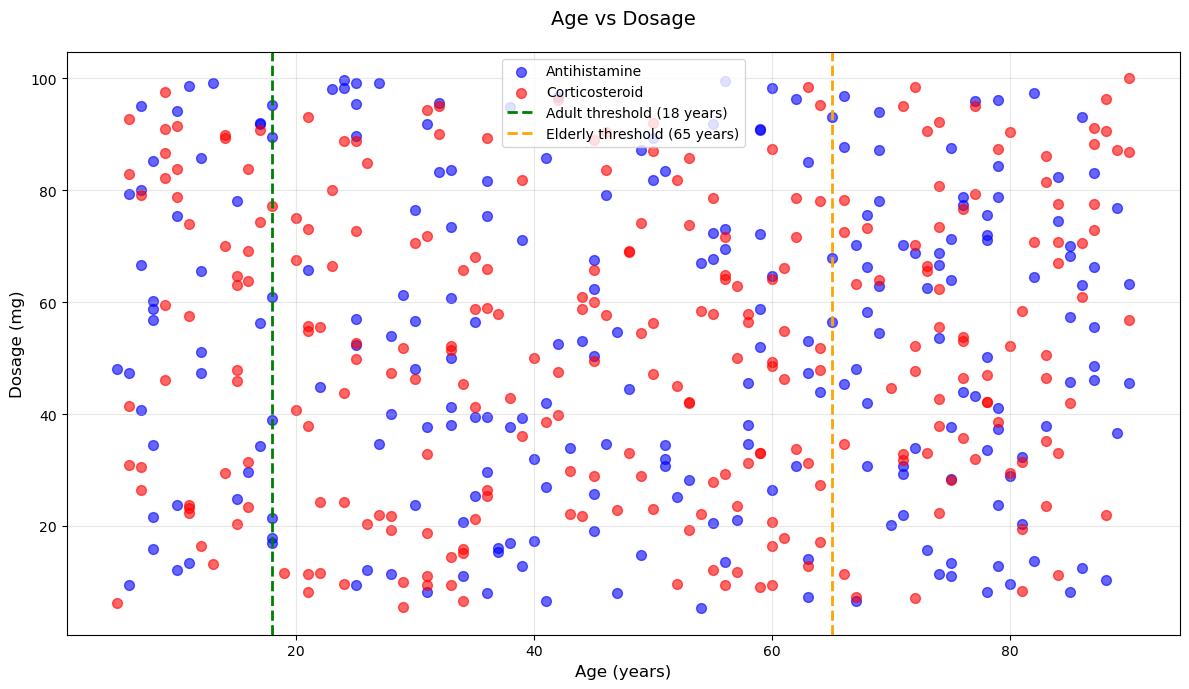

In [14]:
# Age vs dosage
fig, ax = plt.subplots(figsize=(12, 7))

medication_types = train_df['medication_type'].unique()
colors = {'Antihistamine': 'blue', 'Corticosteroid': 'red'}

for med_type in medication_types:
    mask = train_df['medication_type'] == med_type
    ax.scatter(train_df[mask]['age'], 
               train_df[mask]['dosage_mg'],
               c=colors.get(med_type, 'gray'),
               label=med_type,
               alpha=0.6,
               s=50)

ax.axvline(x=18, color='green', linestyle='--', linewidth=2, label='Adult threshold (18 years)')
ax.axvline(x=65, color='orange', linestyle='--', linewidth=2, label='Elderly threshold (65 years)')

ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Dosage (mg)', fontsize=12)
ax.set_title('Age vs Dosage', fontsize=14, pad=20)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


The charts confirm that data is clean and spread out evenly, no outliers found. But there is no simple link between a patient's age and their dosage either dots are mixed randomly with no pattern.

## Statistical analysis

### Chi square test

For categorical features. Normality does not matter.

In [15]:
chi2_results = []

for col in cat_cols:

    temp = train_df[[col, 'response_class']].copy()
    temp[col] = temp[col].fillna('Missing')
    
    contingency = pd.crosstab(temp[col], temp['response_class'])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
    
    result = "Reject H0" if p_value < 0.05 else "Fail to reject H0"
    
    chi2_results.append({
        'Feature': col,
        'Chi2': chi2,
        'p-value': p_value,
        'DoF': dof,
        "Cramér's V": cramers_v,
        'Result': result
    })
    
    sig = "***" if p_value < 0.05 else ""
    print(f"{col:25s}: χ²={chi2:8.3f}, p={p_value:.4f}, V={cramers_v:.3f} {sig}")

chi2_train_df = pd.DataFrame(chi2_results).sort_values('p-value')
print("\n*** = statistically significant at α=0.05")

gender                   : χ²=   9.973, p=0.0409, V=0.100 ***
allergy_type             : χ²=   5.530, p=0.4778, V=0.074 
medication_type          : χ²=   0.331, p=0.8474, V=0.026 
symptom_severity         : χ²=   2.560, p=0.6339, V=0.051 
environmental_exposure   : χ²=   4.609, p=0.3298, V=0.068 
comorbid_conditions      : χ²=   3.626, p=0.4590, V=0.060 
previous_response        : χ²=   3.765, p=0.4387, V=0.061 

*** = statistically significant at α=0.05


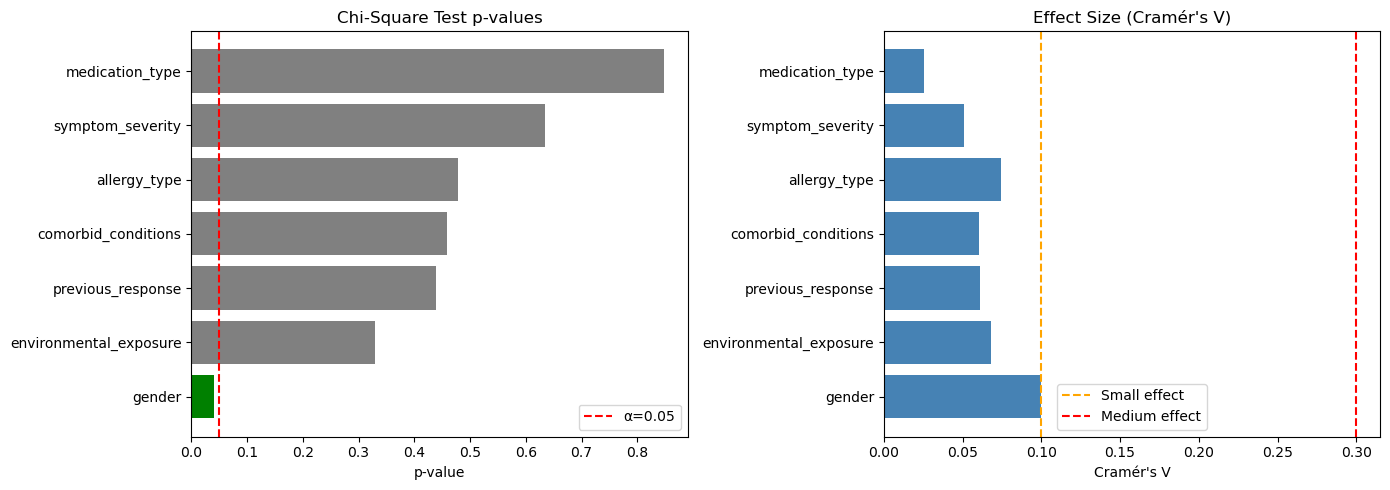

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


colors = ['green' if p < 0.05 else 'gray' for p in chi2_train_df['p-value']]
axes[0].barh(chi2_train_df['Feature'], chi2_train_df['p-value'], color=colors)
axes[0].axvline(x=0.05, color='red', linestyle='--', label='α=0.05')
axes[0].set_xlabel('p-value')
axes[0].set_title('Chi-Square Test p-values')
axes[0].legend()

axes[1].barh(chi2_train_df['Feature'], chi2_train_df["Cramér's V"], color='steelblue')
axes[1].axvline(x=0.1, color='orange', linestyle='--', label='Small effect')
axes[1].axvline(x=0.3, color='red', linestyle='--', label='Medium effect')
axes[1].set_xlabel("Cramér's V")
axes[1].set_title('Effect Size (Cramér\'s V)')
axes[1].legend()

plt.tight_layout()
plt.show()

### ANOVA

For numerical features

In [17]:
num_cols = ['age', 'dosage_mg', 'treatment_duration_days']

for col in num_cols:

    groups = [train_df[train_df['response_class'] == c][col].dropna() 
              for c in train_df['response_class'].unique()]

    f_stat, anova_p = f_oneway(*groups)
    h_stat, kruskal_p = kruskal(*groups)
    
    anova_sig = "***" if anova_p < 0.05 else ""
    kruskal_sig = "***" if kruskal_p < 0.05 else ""
    
    print(f"\n{col}:")
    print(f"  ANOVA:          F={f_stat:8.3f}, p={anova_p:.4f} {anova_sig}")
    print(f"  Kruskal-Wallis: H={h_stat:8.3f}, p={kruskal_p:.4f} {kruskal_sig}")


age:
  ANOVA:          F=   0.288, p=0.7496 
  Kruskal-Wallis: H=   0.494, p=0.7811 

dosage_mg:
  ANOVA:          F=   0.607, p=0.5455 
  Kruskal-Wallis: H=   1.209, p=0.5463 

treatment_duration_days:
  ANOVA:          F=   0.492, p=0.6119 
  Kruskal-Wallis: H=   0.881, p=0.6436 


In [18]:
# to check if ANOVA assumptions are met
num_cols = ['age', 'dosage_mg', 'treatment_duration_days']

print(f"{'FEATURE':<25} | {'NORMALITY':<10} | {'VARIANCE':<10} | {'TRUSTED RESULT':<25}")
print("=" * 85)

for col in num_cols:
    groups = [train_df[train_df['response_class'] == c][col].dropna() 
              for c in train_df['response_class'].unique()]

    is_normal = all(shapiro(g)[1] > 0.05 for g in groups)
    stat_lev, p_lev = levene(*groups)
    equal_variance = p_lev > 0.05
    

    f_stat, anova_p = f_oneway(*groups)     
    h_stat, kruskal_p = kruskal(*groups)    
    if is_normal and equal_variance:
        test_used = "ANOVA"
        p_val = anova_p
        validity = "Assumptions Met"
    else:
        test_used = "Kruskal-Wallis" 
        p_val = kruskal_p
        validity = "Assumptions Failed -> Fallback"
        
    sig = "***" if p_val < 0.05 else ""
    
    norm_str = "Pass" if is_normal else "Fail" 
    var_str = "Pass" if equal_variance else "Fail"
    
    print(f"{col:<25} | {norm_str:<10} | {var_str:<10} | {test_used}: p={p_val:.4f} {sig}")

FEATURE                   | NORMALITY  | VARIANCE   | TRUSTED RESULT           
age                       | Fail       | Pass       | Kruskal-Wallis: p=0.7811 
dosage_mg                 | Fail       | Pass       | Kruskal-Wallis: p=0.5463 
treatment_duration_days   | Fail       | Pass       | Kruskal-Wallis: p=0.6436 


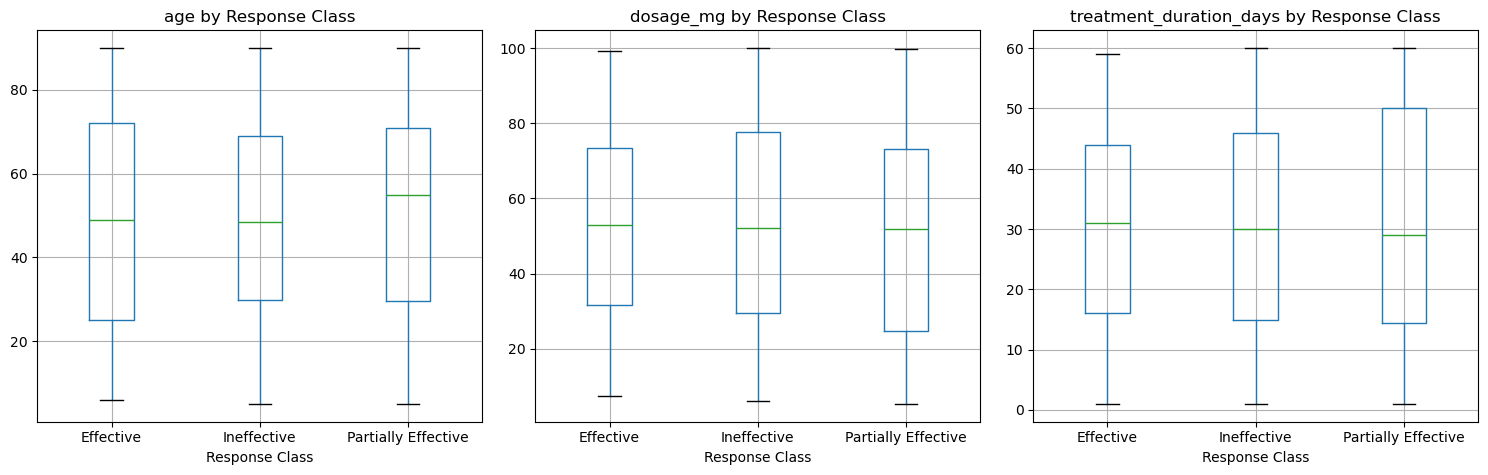

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(num_cols):
    train_df.boxplot(column=col, by='response_class', ax=axes[i])
    axes[i].set_title(f'{col} by Response Class')
    axes[i].set_xlabel('Response Class')
    
plt.suptitle('')
plt.tight_layout()
plt.show()

All three numerical features (age, dosage_mg, treatment_duration_days) failed the Shapiro-Wilk test, which means the data is not bell-shaped, so I can't trust ANOVA. But Kruskal-Wallis results can be trusted. \
No significant features here (i.e. age, dosage and treatment are almost the same for patients with good and bad results). So there is no way to use this data for logistic regression etc.

### Correlation

In [20]:

corr_matrix = train_df[num_cols].corr(method='pearson')
print("\nPearson Correlation:")
print(corr_matrix.round(3))

spearman_matrix = train_df[num_cols].corr(method='spearman')
print("\nSpearman Correlation:")
print(spearman_matrix.round(3))


Pearson Correlation:
                           age  dosage_mg  treatment_duration_days
age                      1.000      0.019                   -0.008
dosage_mg                0.019      1.000                    0.013
treatment_duration_days -0.008      0.013                    1.000

Spearman Correlation:
                           age  dosage_mg  treatment_duration_days
age                      1.000      0.022                   -0.004
dosage_mg                0.022      1.000                    0.013
treatment_duration_days -0.004      0.013                    1.000


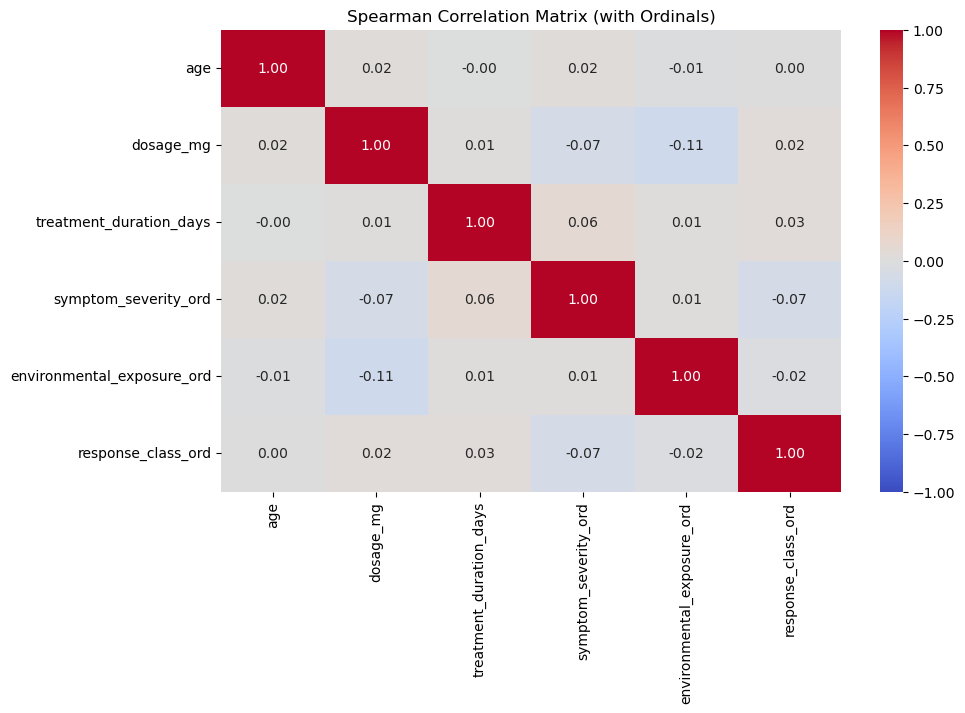

In [21]:
cols_to_check = [
    'age', 'dosage_mg', 'treatment_duration_days', 
    'symptom_severity_ord', 'environmental_exposure_ord',
    'response_class_ord'
]

plt.figure(figsize=(10, 6))
corr_matrix = train_df[cols_to_check].corr(method='spearman')


sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Spearman Correlation Matrix (with Ordinals)")
plt.show()

In [22]:
for col in cols_to_check:
    corr, p_value = spearmanr(train_df[col], train_df['response_class_ord'])
    sig = "***" if p_value < 0.05 else ""
    print(f"{col:25s}: ρ={corr:+.4f}, p={p_value:.4f} {sig}")

age                      : ρ=+0.0036, p=0.9358 
dosage_mg                : ρ=+0.0240, p=0.5918 
treatment_duration_days  : ρ=+0.0263, p=0.5579 
symptom_severity_ord     : ρ=-0.0682, p=0.1276 
environmental_exposure_ord: ρ=-0.0199, p=0.6569 
response_class_ord       : ρ=+1.0000, p=0.0000 ***


This matrix also shows that the features are weak, the correlation shows no linear relationships between the features. Since X don't predict Y, I am going to create feature combinations.

## Feature engineering

In [23]:
target_encoding = {
    'Ineffective': 0,
    'Partially Effective': 1,
    'Effective': 2
}
train_df['target_ord'] = train_df['response_class'].map(target_encoding)

In [24]:
# Age groups
train_df['is_child'] = (train_df['age'] < 18).astype(int)
train_df['is_elderly'] = (train_df['age'] >= 65).astype(int)
train_df['age_group'] = pd.cut(train_df['age'], bins=[0, 12, 18, 35, 50, 65, 100],
                         labels=['child', 'teen', 'young_adult', 'adult', 'middle', 'senior'])

# Dosage features
train_df['dosage_per_severity'] = train_df['dosage_mg'] / (train_df['symptom_severity_ord'] + 1) #no division by 0
train_df['dosage_intensity'] = train_df['dosage_mg'] / (train_df['treatment_duration_days'] + 1)
train_df['dosage_per_day'] = train_df['dosage_mg'] / (train_df['treatment_duration_days'] + 1)

# Combination features 
train_df['gender_severity'] = train_df['gender'] + '_' + train_df['symptom_severity']
train_df['gender_medication'] = train_df['gender'] + '_' + train_df['medication_type']
train_df['allergy_medication'] = train_df['allergy_type'] + '_' + train_df['medication_type']
train_df['severity_medication'] = train_df['symptom_severity'] + '_' + train_df['medication_type']
train_df['gender_age_group'] = train_df['gender'] + '_' + train_df['age_group'].astype(str)
train_df['comorbid_severity'] = train_df['comorbid_conditions'] + '_' + train_df['symptom_severity']



In [25]:
# Encoding 
new_cat_cols = [
    'age_group',
    'gender_severity', 'gender_medication', 
    'allergy_medication', 'severity_medication',
    'gender_age_group', 'comorbid_severity'
]

train_df_corr = train_df.copy()
le = LabelEncoder()

for col in new_cat_cols:
    train_df_corr[col] = train_df_corr[col].astype(str)
    train_df_corr[col] = le.fit_transform(train_df_corr[col])


In [26]:
cat_features = [ 'gender_severity', 'severity_medication',
            'age_group', 'gender', 'comorbid_severity']

In [27]:
# Test feature importance
all_features = [
    'age', 'dosage_mg', 'treatment_duration_days', 'symptom_severity_ord', 'environmental_exposure_ord',
    'dosage_per_severity', 'dosage_intensity', 'dosage_per_day',
    *new_cat_cols 
]


correlations = train_df_corr[all_features].corrwith(train_df_corr['target_ord'], method='spearman')
correlations = correlations.abs().sort_values(ascending=False)

print("Feature Importance (Spearman Correlation)")
print(correlations.head(20))

Feature Importance (Spearman Correlation)
gender_severity               0.071998
symptom_severity_ord          0.068234
dosage_per_severity           0.068040
severity_medication           0.064055
age_group                     0.054979
gender_medication             0.045025
comorbid_severity             0.039079
gender_age_group              0.026733
treatment_duration_days       0.026267
allergy_medication            0.025898
dosage_mg                     0.024036
environmental_exposure_ord    0.019913
age                           0.003611
dosage_intensity              0.000215
dosage_per_day                0.000215
dtype: float64


In [28]:
# Choose top 5 + essentials
final_features = [ 'gender_severity', 'severity_medication', 'symptom_severity_ord', 'dosage_intensity',
            'age_group', 'gender', 'comorbid_severity', 'age', 'dosage_mg', 'treatment_duration_days']

In [29]:

X = train_df[final_features]
y = train_df['target_ord']


In [30]:
X.head()

,gender_severity,severity_medication,symptom_severity_ord,dosage_intensity,age_group,gender,comorbid_severity,age,dosage_mg,treatment_duration_days
0,Female_Mild,Mild_Antihistamine,0,2.962500,child,Female,Asthma_Mild,6,47.4,15
1,Male_Severe,Severe_Antihistamine,2,0.172727,child,Male,Eczema_Severe,6,9.5,54
2,Male_Severe,Severe_Corticosteroid,2,0.855000,middle,Male,Asthma_Severe,64,17.1,19
3,Male_Severe,Severe_Antihistamine,2,1.255556,young_adult,Male,Asthma_Severe,35,56.5,44
4,Other_Moderate,Moderate_Corticosteroid,1,2.018182,young_adult,Other,Eczema_Moderate,25,88.8,43


In [31]:
# Encode categorical features for sklearn models (LightGBM and RandomForest)
label_encoders = {}
X_encoded = X.copy()

for col in cat_features:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le

print("Categorical features encoded!")
X_encoded.head()

Categorical features encoded!


,gender_severity,severity_medication,symptom_severity_ord,dosage_intensity,age_group,gender,comorbid_severity,age,dosage_mg,treatment_duration_days
0,0,0,0,2.962500,1,0,0,6,47.4,15
1,5,4,2,0.172727,1,1,5,6,9.5,54
2,5,5,2,0.855000,2,1,2,64,17.1,19
3,5,4,2,1.255556,5,1,2,35,56.5,44
4,7,3,1,2.018182,5,2,4,25,88.8,43


Looks like these new features are not very helpful. This mathematically proves that even combining multiple data points fails to create a meaningful signal, so the dataset seems to lack necessary information for our prediction.

## Supervised learning 

I am going to use only one model (CatBoost) because it handles categorical features which minimizes overfitting on small datasets.

### CatBoost

In [32]:

# Training (Stratified CV)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cat_acc_scores = []
cat_auc_scores = []
cat_f1_scores = []

print("\nCross-Validation")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = CatBoostClassifier(
        iterations=500,
        depth=4,
        learning_rate=0.03,
        cat_features=cat_features,
        verbose=0,
        eval_metric='MultiClass',
        allow_writing_files=False
    )
    
    model.fit(X_train, y_train)
    
    probs = model.predict_proba(X_val)
    preds = model.predict(X_val)
    
    auc = roc_auc_score(y_val, probs, multi_class='ovr')
    f1 = f1_score(y_val, preds, average="weighted")
    acc = accuracy_score(y_val, preds)
    
    cat_acc_scores.append(acc)
    cat_auc_scores.append(auc)
    cat_f1_scores.append(f1)
    
    print(f"Fold {fold+1} | AUC: {auc:.4f} | ACC: {acc:.4f}| F1-Score: {f1:.4f}")

print("-" * 40)

print(f"Mean AUC: {np.mean(cat_auc_scores):.4f}")
print(f"Mean ACC: {np.mean(cat_acc_scores):.4f}")
print(f"Mean F1:  {np.mean(cat_f1_scores):.4f}")


Cross-Validation
Fold 1 | AUC: 0.5288 | ACC: 0.3400| F1-Score: 0.3127
Fold 2 | AUC: 0.5716 | ACC: 0.4100| F1-Score: 0.3591
Fold 3 | AUC: 0.4454 | ACC: 0.3200| F1-Score: 0.2787
Fold 4 | AUC: 0.5290 | ACC: 0.3500| F1-Score: 0.3139
Fold 5 | AUC: 0.5246 | ACC: 0.3600| F1-Score: 0.3209
----------------------------------------
Mean AUC: 0.5199
Mean ACC: 0.3560
Mean F1:  0.3171


### LightGBM

In [33]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lgbm_auc_scores = []
lgbm_f1_scores = []
lgbm_acc_scores = []

print("LightGBM Cross-Validation (3-class)")
print("=" * 50)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_encoded, y)):
    X_train, X_val = X_encoded.iloc[train_idx], X_encoded.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    lgbm_model = LGBMClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        num_leaves=15,
        min_child_samples=20,
        random_state=RANDOM_STATE,
        verbose=-1
    )
    
    lgbm_model.fit(X_train, y_train)
    
    probs = lgbm_model.predict_proba(X_val)
    preds = lgbm_model.predict(X_val)
    
    auc = roc_auc_score(y_val, probs, multi_class='ovr')
    f1 = f1_score(y_val, preds, average='weighted')
    acc = accuracy_score(y_val, preds)
    
    lgbm_auc_scores.append(auc)
    lgbm_f1_scores.append(f1)
    lgbm_acc_scores.append(acc)
    
    print(f"Fold {fold+1} | AUC: {auc:.4f} | F1: {f1:.4f} | Acc: {acc:.4f}")

print("-" * 50)
print(f"Mean AUC: {np.mean(lgbm_auc_scores):.4f} (+/- {np.std(lgbm_auc_scores):.4f})")
print(f"Mean F1:  {np.mean(lgbm_f1_scores):.4f} (+/- {np.std(lgbm_f1_scores):.4f})")
print(f"Mean Acc: {np.mean(lgbm_acc_scores):.4f} (+/- {np.std(lgbm_acc_scores):.4f})")

LightGBM Cross-Validation (3-class)
Fold 1 | AUC: 0.5368 | F1: 0.3914 | Acc: 0.3900
Fold 2 | AUC: 0.5911 | F1: 0.4274 | Acc: 0.4300
Fold 3 | AUC: 0.5113 | F1: 0.3089 | Acc: 0.3200
Fold 4 | AUC: 0.4601 | F1: 0.2907 | Acc: 0.2900
Fold 5 | AUC: 0.5229 | F1: 0.3824 | Acc: 0.3900
--------------------------------------------------
Mean AUC: 0.5244 (+/- 0.0422)
Mean F1:  0.3602 (+/- 0.0519)
Mean Acc: 0.3640 (+/- 0.0512)


### Random Forest

In [34]:
rf_auc_scores = []
rf_f1_scores = []
rf_acc_scores = []

print("Random Forest Cross-Validation (3-class)")
print("=" * 50)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_encoded, y)):
    X_train, X_val = X_encoded.iloc[train_idx], X_encoded.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    rf_model.fit(X_train, y_train)
    
    probs = rf_model.predict_proba(X_val)
    preds = rf_model.predict(X_val)
    
    auc = roc_auc_score(y_val, probs, multi_class='ovr')
    f1 = f1_score(y_val, preds, average='weighted')
    acc = accuracy_score(y_val, preds)
    
    rf_auc_scores.append(auc)
    rf_f1_scores.append(f1)
    rf_acc_scores.append(acc)
    
    print(f"Fold {fold+1} | AUC: {auc:.4f} | F1: {f1:.4f} | Acc: {acc:.4f}")

print("-" * 50)
print(f"Mean AUC: {np.mean(rf_auc_scores):.4f} (+/- {np.std(rf_auc_scores):.4f})")
print(f"Mean F1:  {np.mean(rf_f1_scores):.4f} (+/- {np.std(rf_f1_scores):.4f})")
print(f"Mean Acc: {np.mean(rf_acc_scores):.4f} (+/- {np.std(rf_acc_scores):.4f})")

Random Forest Cross-Validation (3-class)
Fold 1 | AUC: 0.5434 | F1: 0.3407 | Acc: 0.3700
Fold 2 | AUC: 0.5733 | F1: 0.3485 | Acc: 0.4000
Fold 3 | AUC: 0.4481 | F1: 0.2534 | Acc: 0.2800
Fold 4 | AUC: 0.5092 | F1: 0.2964 | Acc: 0.3200
Fold 5 | AUC: 0.5110 | F1: 0.3095 | Acc: 0.3400
--------------------------------------------------
Mean AUC: 0.5170 (+/- 0.0417)
Mean F1:  0.3097 (+/- 0.0341)
Mean Acc: 0.3420 (+/- 0.0412)


### Voting Ensemble

In [35]:
ens_auc_scores = []
ens_f1_scores = []
ens_acc_scores = []

print("Voting Ensemble Cross-Validation (3-class)")
print("=" * 50)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_encoded, y)):
    X_train, X_val = X_encoded.iloc[train_idx], X_encoded.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    

    lgbm = LGBMClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        num_leaves=15, random_state=RANDOM_STATE, verbose=-1
    )
    
    rf = RandomForestClassifier(
        n_estimators=200, max_depth=5, min_samples_split=10,
        min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1
    )
    
    catboost = CatBoostClassifier(
        iterations=300, depth=4, learning_rate=0.05,
        random_state=RANDOM_STATE, verbose=0
    )
    
    ensemble = VotingClassifier(
        estimators=[('lgbm', lgbm), ('rf', rf), ('catboost', catboost)],
        voting='soft'
    )
    
    ensemble.fit(X_train, y_train)
    
    probs = ensemble.predict_proba(X_val)
    preds = ensemble.predict(X_val)
    
    auc = roc_auc_score(y_val, probs, multi_class='ovr')
    f1 = f1_score(y_val, preds, average='weighted')
    acc = accuracy_score(y_val, preds)
    
    ens_auc_scores.append(auc)
    ens_f1_scores.append(f1)
    ens_acc_scores.append(acc)
    
    print(f"Fold {fold+1} | AUC: {auc:.4f} | F1: {f1:.4f} | Acc: {acc:.4f}")

print("-" * 50)
print(f"Mean AUC: {np.mean(ens_auc_scores):.4f} (+/- {np.std(ens_auc_scores):.4f})")
print(f"Mean F1:  {np.mean(ens_f1_scores):.4f} (+/- {np.std(ens_f1_scores):.4f})")
print(f"Mean Acc: {np.mean(ens_acc_scores):.4f} (+/- {np.std(ens_acc_scores):.4f})")

Voting Ensemble Cross-Validation (3-class)
Fold 1 | AUC: 0.5474 | F1: 0.3757 | Acc: 0.3800
Fold 2 | AUC: 0.5838 | F1: 0.4613 | Acc: 0.4700
Fold 3 | AUC: 0.4790 | F1: 0.3151 | Acc: 0.3300
Fold 4 | AUC: 0.4800 | F1: 0.2852 | Acc: 0.2900
Fold 5 | AUC: 0.5252 | F1: 0.3462 | Acc: 0.3600
--------------------------------------------------
Mean AUC: 0.5231 (+/- 0.0402)
Mean F1:  0.3567 (+/- 0.0604)
Mean Acc: 0.3660 (+/- 0.0602)


## Model Comparison


Model Comparison Summary
          Model  Mean AUC  Mean F1  Mean Acc
       CatBoost  0.519895 0.317051     0.356
       LightGBM  0.524446 0.360172     0.364
  Random Forest  0.516990 0.309682     0.342
Voting Ensemble  0.523101 0.356720     0.366


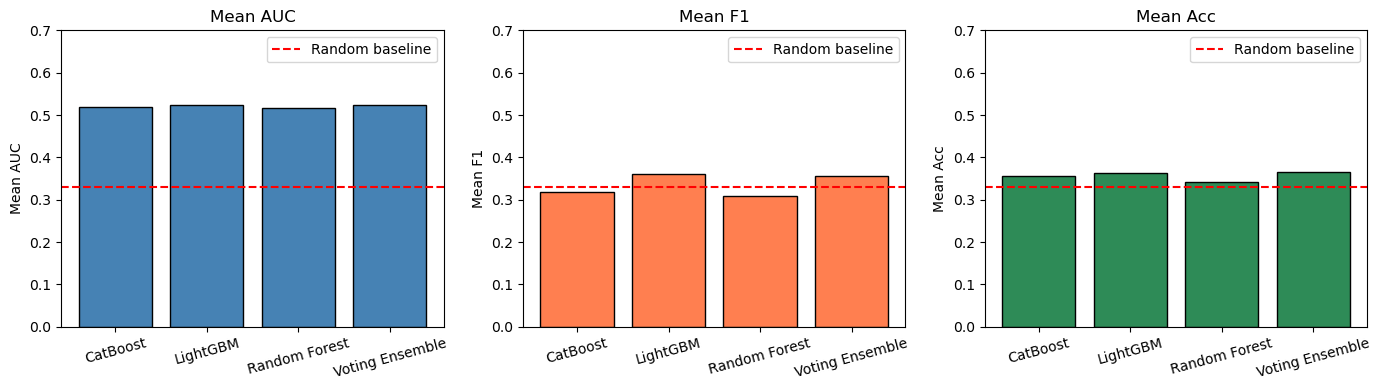

In [36]:
results = pd.DataFrame({
    'Model': ['CatBoost', 'LightGBM', 'Random Forest', 'Voting Ensemble'],
    'Mean AUC': [np.mean(cat_auc_scores), np.mean(lgbm_auc_scores), np.mean(rf_auc_scores), np.mean(ens_auc_scores)],
    'Mean F1': [np.mean(cat_f1_scores), np.mean(lgbm_f1_scores), np.mean(rf_f1_scores), np.mean(ens_f1_scores)],
    'Mean Acc': [np.mean(cat_acc_scores), np.mean(lgbm_acc_scores), np.mean(rf_acc_scores), np.mean(ens_acc_scores)]
})

print("\nModel Comparison Summary")
print("=" * 60)
print(results.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics = ['Mean AUC', 'Mean F1', 'Mean Acc']
colors = ['steelblue', 'coral', 'seagreen']

for i, metric in enumerate(metrics):
    axes[i].bar(results['Model'], results[metric], color=colors[i], edgecolor='black')
    axes[i].axhline(y=0.33, color='red', linestyle='--', label='Random baseline')
    axes[i].set_ylabel(metric)
    axes[i].set_title(metric)
    axes[i].set_ylim(0, 0.7)
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].legend()

plt.tight_layout()
plt.show()

The outcome of the best model (LightGBM) is slightly better than random guessing which means the signal is too weak to predict Y.

## Clustering

Since prediction failed, I pivoted to pattern recognition.

In [37]:
X_cluster = train_df[['age', 'dosage_mg', 'treatment_duration_days', 
                       'symptom_severity_ord', 'environmental_exposure_ord',
                       'dosage_intensity']] 

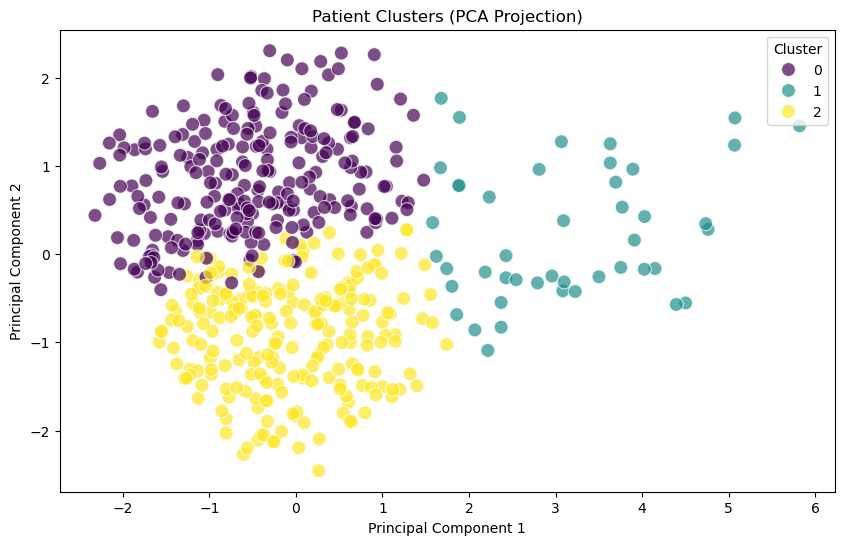


Cluster vs. Original Outcome:
response_class  Effective  Ineffective  Partially Effective
cluster_id                                                 
0                      89           64                   78
1                      13           17                   15
2                      91           67                   66


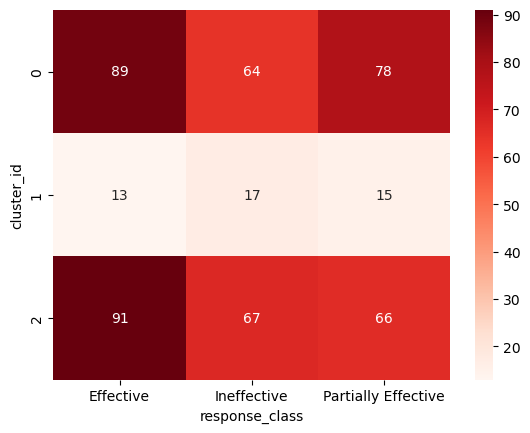

In [38]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Find clusters 
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)


plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis', s=100, alpha=0.7)
plt.title("Patient Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Cluster')
plt.show()

train_df['cluster_id'] = clusters
ct = pd.crosstab(train_df['cluster_id'], train_df['response_class'])
print("\nCluster vs. Original Outcome:")
print(ct)
sns.heatmap(ct, annot=True, fmt='d', cmap='Reds')
plt.show()

It looks like there is a specific group of patients (Cluster 1) defined solely by their high-intensity treatment plan (regardless of age and gender).

In [39]:
train_df[train_df['cluster_id'] == 1].head()

,age,gender,allergy_type,symptom_severity,medication_type,dosage_mg,treatment_duration_days,comorbid_conditions,previous_response,environmental_exposure,...,response_class_ord,target_ord,is_child,is_elderly,dosage_per_severity,dosage_per_day,gender_medication,allergy_medication,gender_age_group,cluster_id
17,84,Male,pollen,Mild,Corticosteroid,77.6,3,Eczema,Good,Low,...,0,0,0,1,77.600000,19.400000,Male_Corticosteroid,pollen_Corticosteroid,Male_senior,1
22,10,Other,food,Severe,Corticosteroid,78.7,9,None,Good,Low,...,0,0,1,0,26.233333,7.870000,Other_Corticosteroid,food_Corticosteroid,Other_child,1
24,14,Other,pet dander,Mild,Corticosteroid,89.3,14,None,Poor,High,...,2,2,1,0,89.300000,5.953333,Other_Corticosteroid,pet dander_Corticosteroid,Other_teen,1
42,18,Other,pet dander,Moderate,Corticosteroid,77.1,3,None,Good,Low,...,2,2,0,0,38.550000,19.275000,Other_Corticosteroid,pet dander_Corticosteroid,Other_teen,1
52,55,Female,dust,Mild,Antihistamine,91.9,5,Asthma,Good,Medium,...,0,0,0,0,91.900000,15.316667,Female_Antihistamine,dust_Antihistamine,Female_middle,1


## Prepare test features

In [40]:

final_features = [
    'gender_severity', 'severity_medication', 'symptom_severity_ord', 'dosage_intensity',
    'age_group', 'gender', 'comorbid_severity', 'age', 'dosage_mg', 'treatment_duration_days'
]

cat_features = ['gender_severity', 'severity_medication', 'age_group', 'gender', 'comorbid_severity']


inverse_map = {0: 'Ineffective', 1: 'Partially Effective', 2: 'Effective'}

X = train_df[final_features].copy()
y = train_df['response_class'].map(target_map)

print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts().sort_index()}")

X shape: (500, 10)
y distribution:
response_class
0    148
1    159
2    193
Name: count, dtype: int64


## Train final model and predict

In [41]:

final_model = LGBMClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    num_leaves=15, random_state=RANDOM_STATE, verbose=-1
)

final_model.fit(X_encoded, y)



LGBMClassifier(learning_rate=0.05, max_depth=4, n_estimators=300, num_leaves=15,
               random_state=42, verbose=-1)

In [42]:

X_test = test_df[final_features].copy()

for col in cat_features:
    le = label_encoders[col]
    X_test[col] = X_test[col].astype(str).apply(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1
    )


test_preds = final_model.predict(X_test)
test_probs = final_model.predict_proba(X_test)

test_labels = [inverse_map[p] for p in test_preds]

print("Prediction distribution:")
print(pd.Series(test_labels).value_counts())

Prediction distribution:
Effective              36
Partially Effective    34
Ineffective            30
Name: count, dtype: int64


In [43]:

test_original = pd.read_excel("test_allergy.xlsx")
test_original['response_class'] = test_labels

test_original.to_excel('wsi ani25 project_Khralovich_Anastasiya.xlsx', index=False)

test_original.head(10)

,age,gender,allergy_type,symptom_severity,medication_type,dosage_mg,treatment_duration_days,comorbid_conditions,previous_response,environmental_exposure,response_class
0,37,Female,pet dander,Severe,Antihistamine,62.5,6,Eczema,NaN,Low,Partially Effective
1,47,Other,pollen,Mild,Corticosteroid,49.2,52,Asthma,Good,Low,Ineffective
2,35,Male,pet dander,Mild,Antihistamine,76.4,28,Eczema,NaN,High,Partially Effective
3,41,Female,pet dander,Moderate,Corticosteroid,86.2,16,NaN,Good,Low,Effective
4,71,Female,dust,Severe,Antihistamine,43.9,1,NaN,Poor,Low,Effective
5,17,Other,pollen,Moderate,Antihistamine,36.9,46,Asthma,Poor,High,Effective
6,36,Male,pollen,Mild,Corticosteroid,21.8,10,Eczema,NaN,Low,Partially Effective
7,38,Other,pet dander,Moderate,Antihistamine,56.6,23,Asthma,NaN,Medium,Ineffective
8,31,Other,food,Moderate,Corticosteroid,10.6,19,Eczema,Poor,High,Partially Effective
9,31,Male,food,Mild,Antihistamine,96.0,43,NaN,NaN,High,Partially Effective


## Summary

I used 3 models and an ensemble to predict which patients would get better results based on administrative data like age, gender and medical history, but this data did not have a strong signal to predict the outcomes for future patients with similar features and the model’s performance remaining near the baseline (AUC 0.55).

However, I did find a hidden pattern: by grouping patients together, I discovered a specific 'High Intensity' group (Cluster 1)_that took strong doses very quickly. This proves that while we cannot predict the final health result, we can clearly see that different patients are being treated in very different ways. 

Possible next steps: get more biological data (test results) and get more data to utilize the "high intensity" cluster. 